# Visualize U-Net predictions

This notebook loads a released model bundle and demonstrates the reusable map panels in `mindthegap.viz`. Evaluation over many dates belongs in `4-U-Net_Evaluation.ipynb`.

In [1]:
from pathlib import Path
import sys

for parent in (Path.cwd(), Path.cwd().parent):
    if (parent / "mindthegap").is_dir():
        sys.path.insert(0, str(parent))
        break

import matplotlib.pyplot as plt
import mindthegap as mtg
from mindthegap import viz

## Load a model bundle

Use a local bundle directory or a Hugging Face repository ID. The metadata supplies the exact channel order and standardization needed for prediction.

In [2]:
bundle_source = "demo-unet-bundle"

if Path(bundle_source).is_dir():
    bundle_path = Path(bundle_source)
else:
    from huggingface_hub import snapshot_download
    bundle_path = Path(snapshot_download(repo_id=bundle_source))

model, metadata = mtg.load_model_bundle(bundle_path)
input_vars = [item["name"] for item in metadata["inputs"]]
print(f"Loaded: {metadata['model']['name']}")
print(f"Inputs: {input_vars}")

2026-08-06 23:58:25.612337: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-06 23:58:25.627098: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786060705.646911   13260 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786060705.653668   13260 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786060705.668510   13260 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Loaded: demo U-Net gap filler
Inputs: ['masked_target', 'masked_target_m1', 'masked_target_p1', 'day_sin', 'day_cos', 'synthetic_missing_flag', 'true_missing_flag', 'valid_masked_target_flag', 'land_flag']


## Prepare matching data

The example below reconstructs the deterministic demo data used by `2-U-Net_Fit_Generic.ipynb`. For another bundle, replace this cell with the matching dataset loader and preprocessing recorded in `model_metadata.yaml`.

In [3]:
ds, _ = mtg.demo_data(days=120, lat_size=16, lon_size=16, seed=42)
ds = mtg.crop_to_multiple(ds, multiple=8)
train_end = metadata["dataset"]["training_period"].split(" to ")[1]
n_lags = metadata["preprocessing"]["transforms"]["temporal_lags"]
standardized_vars = [
    name
    for name, values in metadata["preprocessing"]["standardization"].items()
    if values.get("applied")
]

ds_std, _ = mtg.build_standardized_lazy(
    ds,
    target_variable="chlor_a",
    missing_flag="cloud_flag",
    land_flag="land_flag",
    train_dates=slice(str(ds.time.values[0])[:10], train_end),
    std_vars=standardized_vars,
    log_target=True,
    missing_flag_shift=10,
    n_temporal_lags=n_lags,
    output_chunks={"time": 20, "lat": 16, "lon": 16},
)

missing_inputs = [name for name in input_vars if name not in ds_std]
if missing_inputs:
    raise ValueError(f"Prepared dataset is missing bundle inputs: {missing_inputs}")
ds_std

<xarray.Dataset> Size: 861kB
Dimensions:                   (time: 120, lat: 16, lon: 16)
Coordinates:
  * time                      (time) datetime64[ns] 960B 2020-01-01 ... 2020-...
  * lat                       (lat) float64 128B 31.0 29.27 27.53 ... 6.733 5.0
  * lon                       (lon) float64 128B 42.0 44.53 47.07 ... 77.47 80.0
Data variables:
    full_target               (time, lat, lon) float32 123kB dask.array<chunksize=(20, 16, 16), meta=np.ndarray>
    masked_target             (time, lat, lon) float32 123kB dask.array<chunksize=(20, 16, 16), meta=np.ndarray>
    masked_target_m1          (time, lat, lon) float32 123kB dask.array<chunksize=(20, 16, 16), meta=np.ndarray>
    masked_target_p1          (time, lat, lon) float32 123kB dask.array<chunksize=(20, 16, 16), meta=np.ndarray>
    day_sin                   (time, lat, lon) float32 123kB dask.array<chunksize=(20, 16, 16), meta=np.ndarray>
    day_cos                   (time, lat, lon) float32 123kB dask.array<chunksize=(20, 16, 16), meta=np.ndarray>
    synthetic_missing_flag    (time, lat, lon) int8 31kB dask.array<chunksize=(20, 16, 16), meta=np.ndarray>
    true_missing_flag         (time, lat, lon) int8 31kB dask.array<chunksize=(20, 16, 16), meta=np.ndarray>
    valid_masked_target_flag  (time, lat, lon) int8 31kB dask.array<chunksize=(20, 16, 16), meta=np.ndarray>
    land_flag                 (time, lat, lon) int8 31kB dask.array<chunksize=(20, 16, 16), meta=np.ndarray>

## Individual panels

Each panel is available independently, so custom layouts do not duplicate plotting or prediction logic.

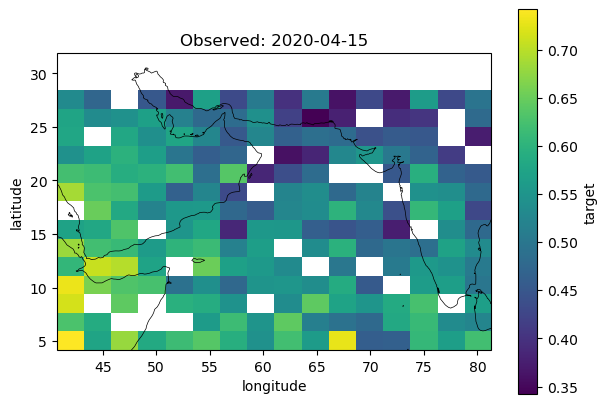

2026-08-06 23:58:33.257947: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


2026-08-06 23:58:33.585869: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.40 = (f32[1,64,16,16]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,9,16,16]{3,2,1,0} %bitcast.712, f32[64,9,3,3]{3,2,1,0} %bitcast.719, f32[64]{0} %bitcast.721), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="U-net_1/conv2d_1/convolution" source_file="/srv/conda/envs/notebook/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2026-08-06 23:58:33.644754: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially b

2026-08-06 23:58:33.790475: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.45 = (f32[1,256,4,4]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,256,4,4]{3,2,1,0} %bitcast.828, f32[256,256,3,3]{3,2,1,0} %bitcast.835, f32[256]{0} %bitcast.837), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="U-net_1/conv2d_5_1/convolution" source_file="/srv/conda/envs/notebook/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2026-08-06 23:58:33.883504: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentia

2026-08-06 23:58:34.056859: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.49 = (f32[1,64,8,8]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,128,8,8]{3,2,1,0} %bitcast.947, f32[64,128,3,3]{3,2,1,0} %bitcast.954, f32[64]{0} %bitcast.956), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="U-net_1/conv2d_8_1/convolution" source_file="/srv/conda/envs/notebook/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2026-08-06 23:58:34.091597: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially

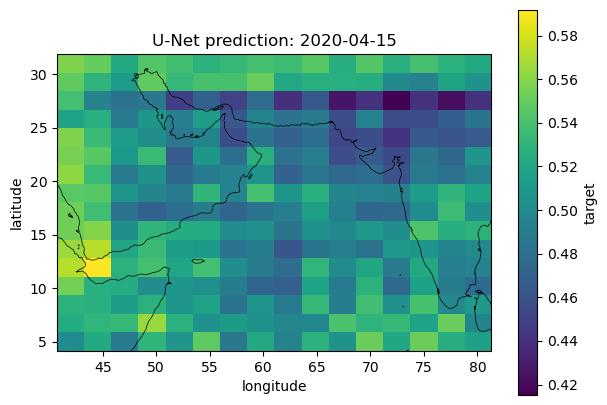

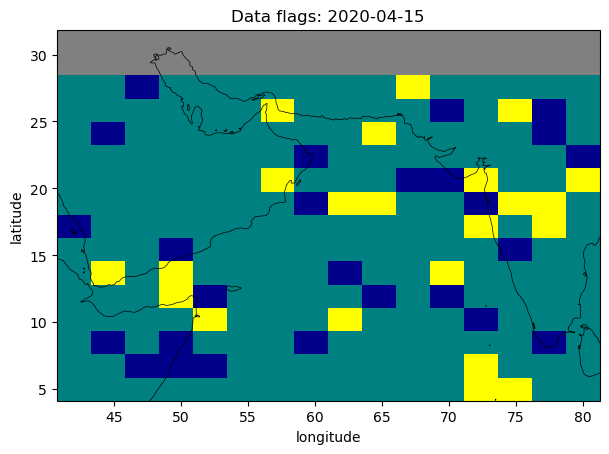

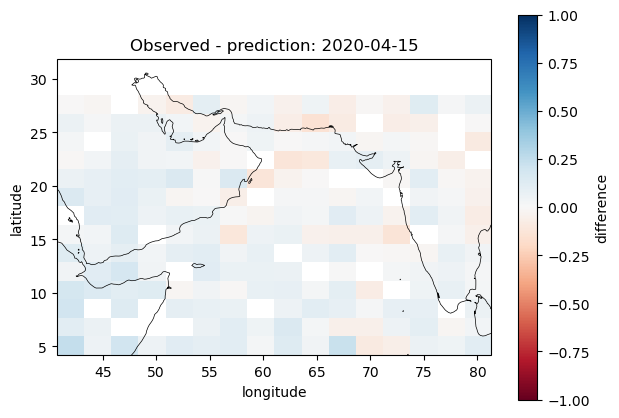

In [4]:
date = "2020-04-15"

viz.plot_observed(ds_std, metadata, date)
viz.plot_prediction(ds_std, model, metadata, date)
viz.plot_flags(ds_std, date)
viz.plot_difference(ds_std, model, metadata, date)

## Standard four-panel view

The composite calls the same individual panel functions and predicts only once.

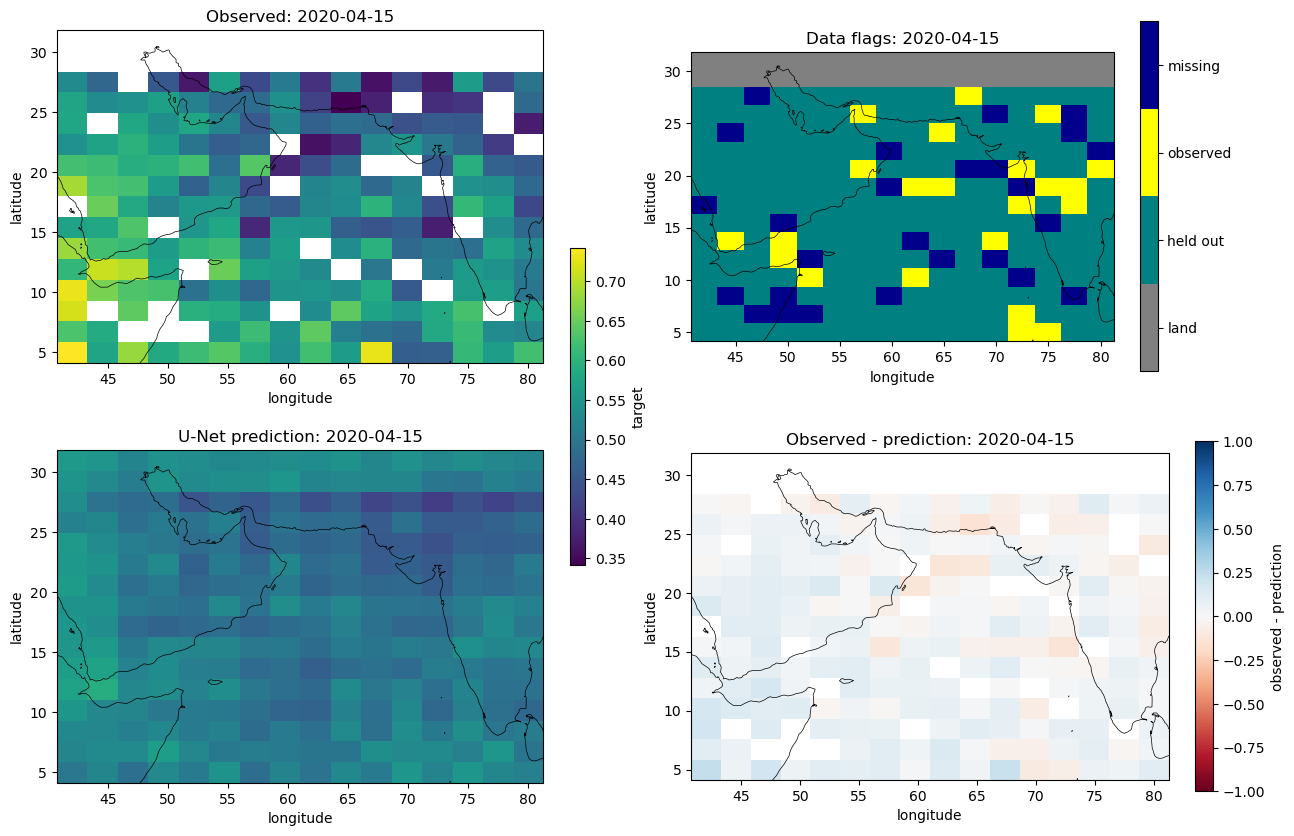

In [5]:
fig, axes = viz.plot_prediction_observed(
    ds_std,
    model,
    metadata,
    date,
    difference_limit=1.0,
)
plt.show()